# Exploratory Data Analysis
### Customer Churn Prediction

This notebook checks the Telco churn dataset and looks for the main patterns that matter for modeling.

Dataset: Telco Customer Churn (IBM / Kaggle)  
Target: `Churn` (Yes / No)

## Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Load the data

Read the CSV file and show the first rows so we can confirm the dataset loaded correctly.

In [2]:
df = pd.read_csv('../data/telco_churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Basic overview

Check the shape, data types and missing values before doing more detailed analysis.

In [3]:
print('Shape:', df.shape)
print('\nColumn types:')
print(df.dtypes)

print('\nMissing values:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

Shape: (7043, 21)

Column types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
No missing values found.


In [4]:
# TotalCharges is often stored as str — fix it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('Missing after TotalCharges fix:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing after TotalCharges fix:
TotalCharges    11
dtype: int64


In [5]:
print('Numeric summary:')
df.describe()

Numeric summary:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [6]:
print('Categorical summary:')
df.describe(include='object')

Categorical summary:


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


## 3. Target variable

We want to see how many customers churned and whether the target classes are balanced.

Churn distribution:
  No: 5174 (73.5%)
  Yes: 1869 (26.5%)


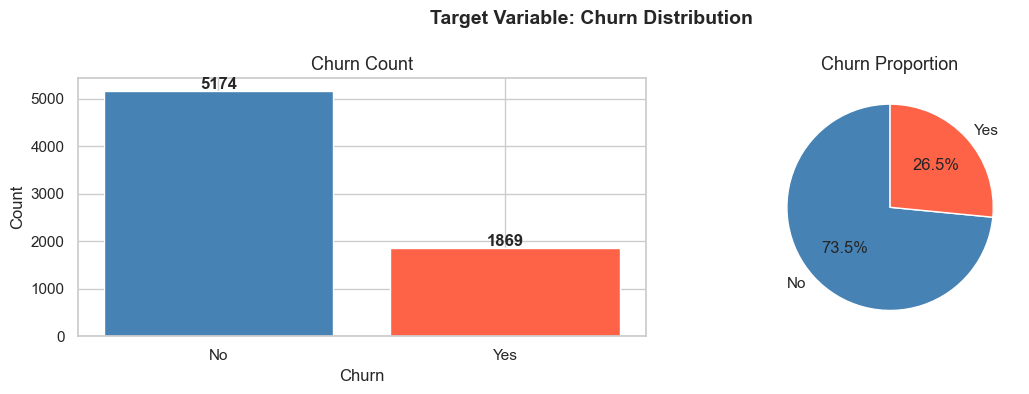


Dataset is imbalanced: about 73% No and 27% Yes.


In [7]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('Churn distribution:')
for label in churn_counts.index:
    print(f'  {label}: {churn_counts[label]} ({churn_pct[label]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(churn_counts.index, churn_counts.values, color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Churn Count', fontsize=13)
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Churn Proportion', fontsize=13)

plt.suptitle('Target Variable: Churn Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nDataset is imbalanced: about 73% No and 27% Yes.')

## 4. Numeric features

Compare the main numeric fields for churned and non-churned customers.

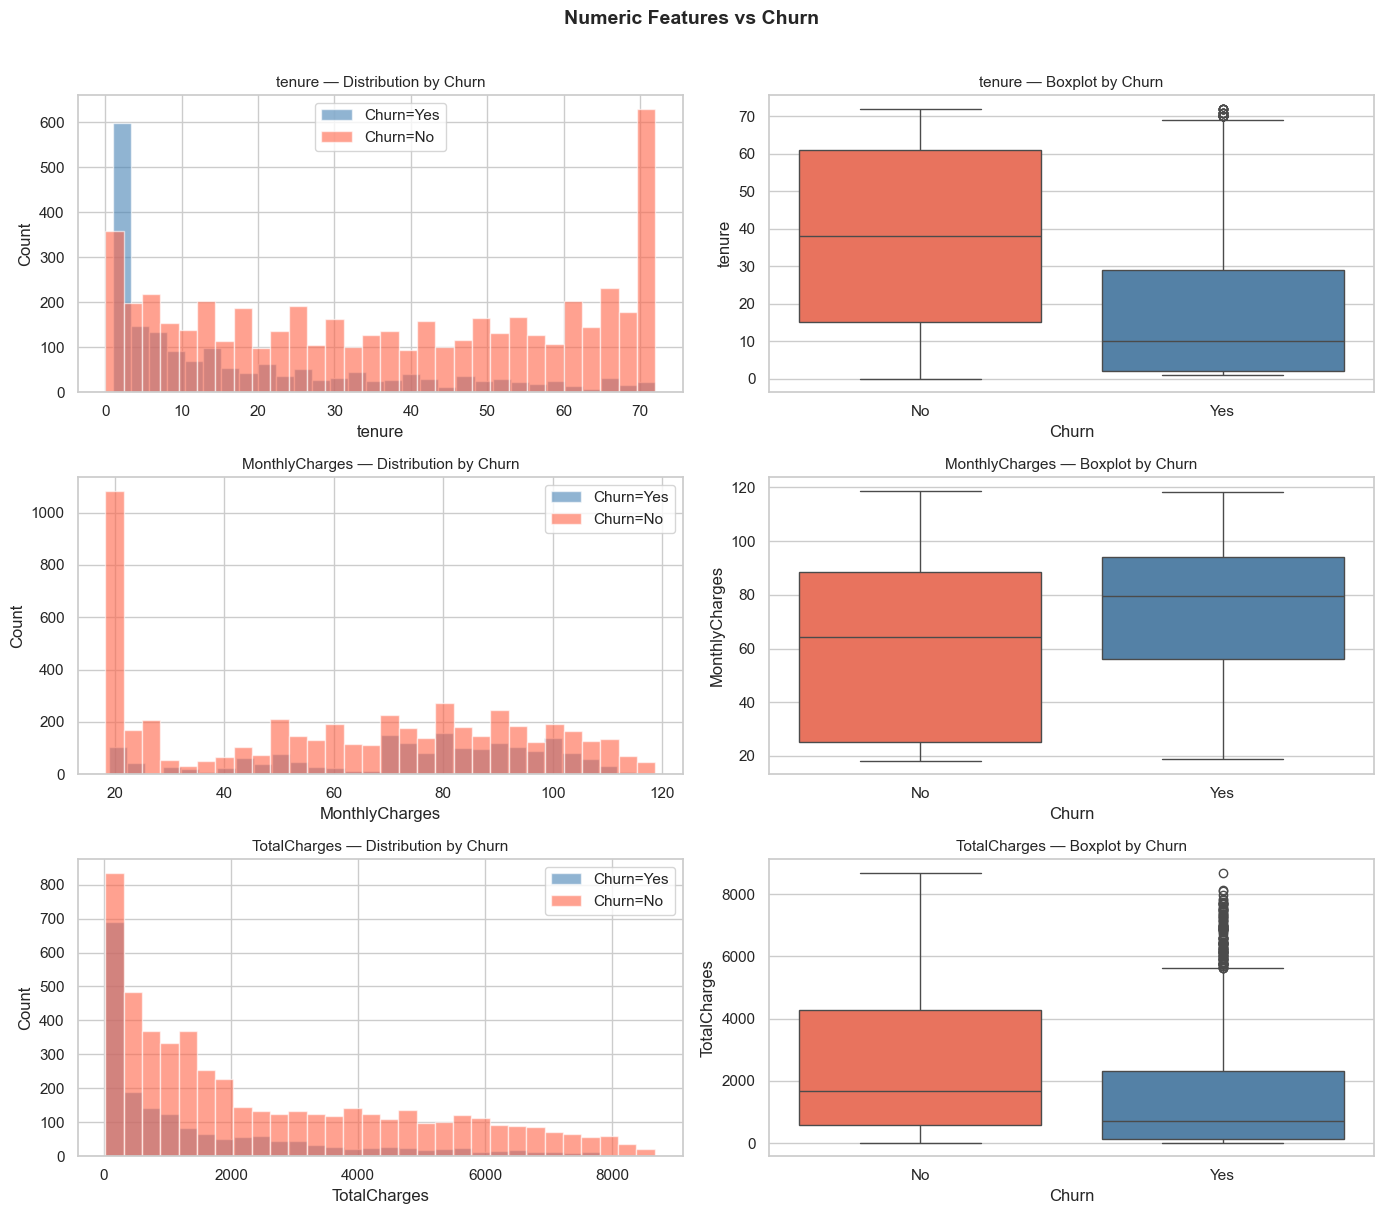

In [8]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    # Distribution
    for label, color in zip(['Yes','No'], ['steelblue','tomato']):
        subset = df[df['Churn'] == label][col].dropna()
        axes[i][0].hist(subset, bins=30, alpha=0.6, label=f'Churn={label}', color=color, edgecolor='white')
    axes[i][0].set_title(f'{col} — Distribution by Churn', fontsize=11)
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('Count')
    axes[i][0].legend()

    # Boxplot
    sns.boxplot(data=df, x='Churn', y=col, palette={'Yes': 'steelblue', 'No': 'tomato'}, ax=axes[i][1])
    axes[i][1].set_title(f'{col} — Boxplot by Churn', fontsize=11)

plt.suptitle('Numeric Features vs Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [9]:
print('Numeric stats by churn:')
df.groupby('Churn')[numeric_cols].agg(['mean', 'median']).round(2)

Numeric stats by churn:


tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
No     37.57   38.0          61.27  64.43      2555.34  1683.60
Yes    17.98   10.0          74.44  79.65      1531.80   703.55

Key observations:
- `tenure`: churned customers tend to have lower tenure
- `MonthlyCharges`: churned customers tend to have higher monthly charges
- `TotalCharges`: correlated with tenure and lower for churned customers

## 5. Categorical features

Look at churn rate within each category to find the strongest categorical drivers.

In [10]:
# Identify categorical columns (excluding customerID and target)
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['customerID', 'Churn']]
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

Categorical columns (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


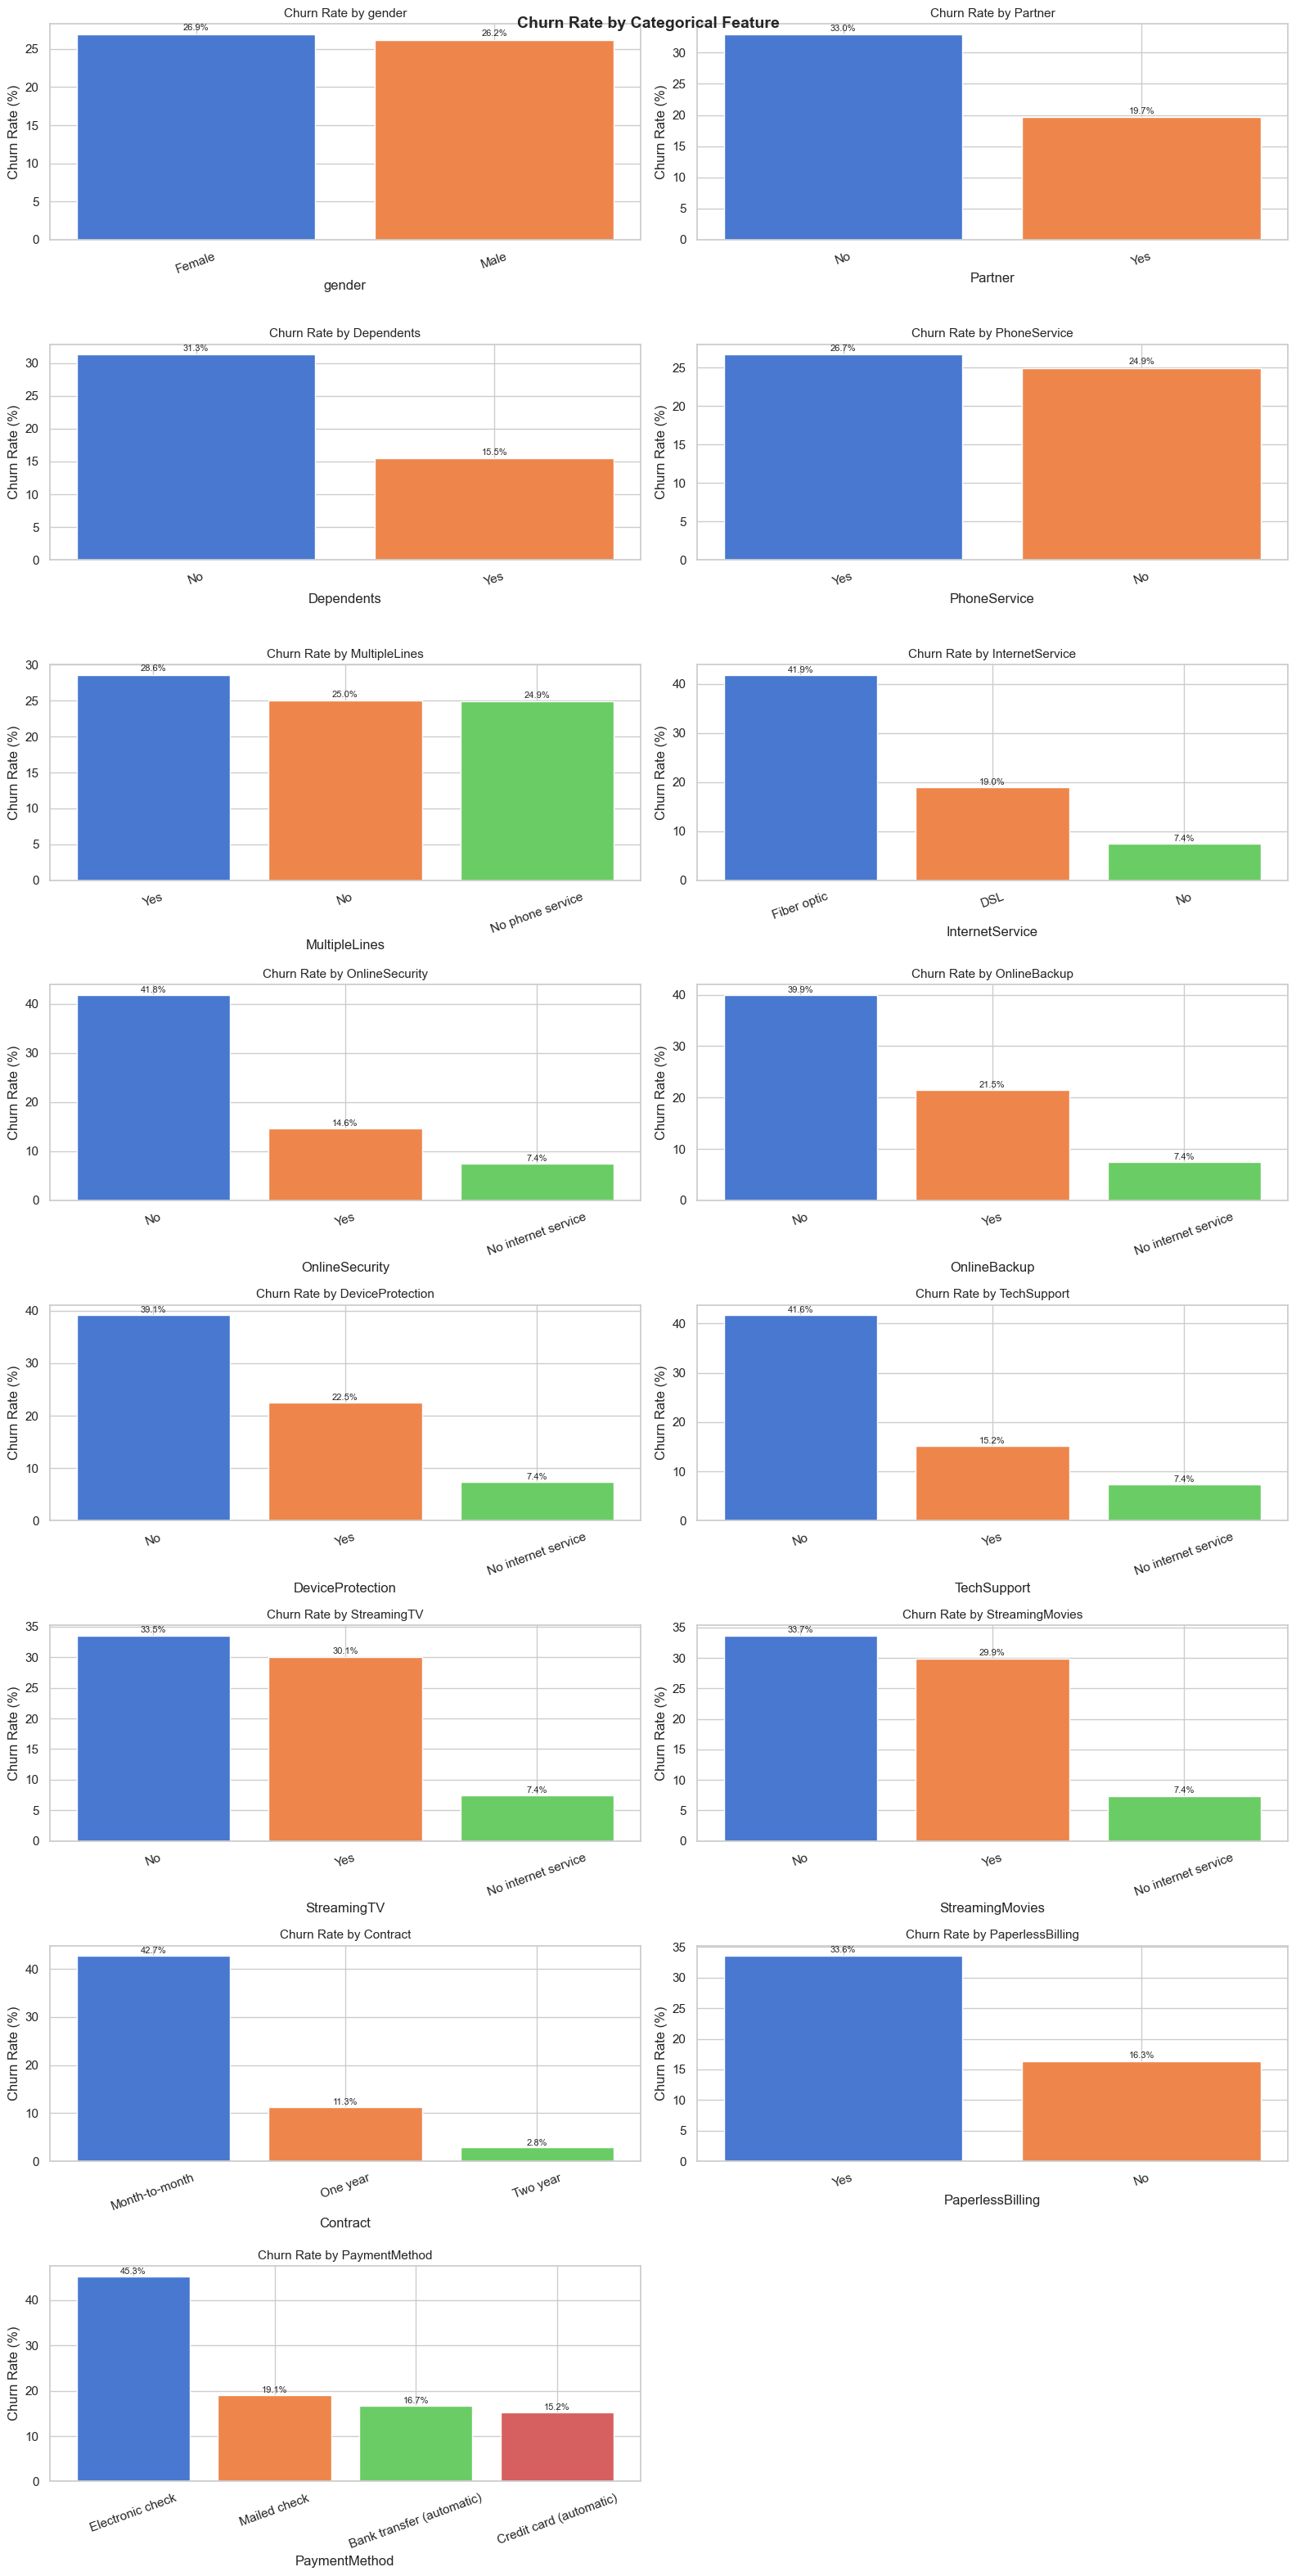

In [11]:
# Churn rate per category for each categorical feature
n_cols = 2
n_rows = (len(cat_cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    churn_rate.columns = [col, 'ChurnRate']
    churn_rate = churn_rate.sort_values('ChurnRate', ascending=False)

    bars = axes[i].bar(churn_rate[col], churn_rate['ChurnRate'],
                       color=sns.color_palette('muted', len(churn_rate)), edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=20)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{bar.get_height():.1f}%', ha='center', fontsize=8)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Categorical Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Correlation

Check how the numeric features are related to churn and to each other.

Correlation with churn:
tenure           -0.352
TotalCharges     -0.199
MonthlyCharges    0.193
Name: Churn_binary, dtype: float64


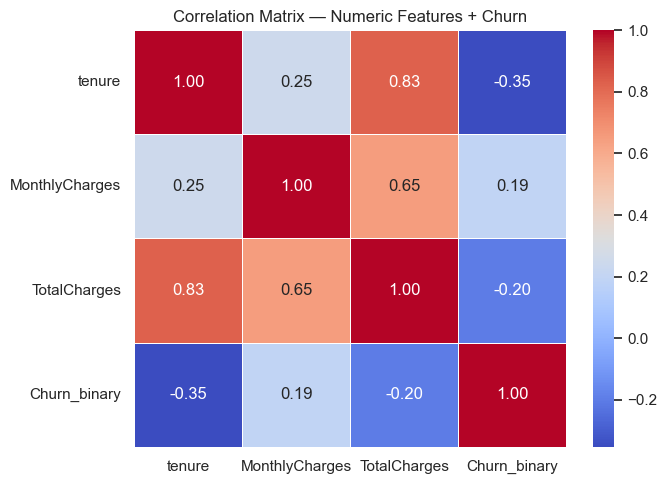

In [12]:
# Encode Churn as binary for correlation
df_corr = df.copy()
df_corr['Churn_binary'] = (df_corr['Churn'] == 'Yes').astype(int)

# Correlation of numeric features with Churn
print('Correlation with churn:')
corr_with_churn = df_corr[numeric_cols + ['Churn_binary']].corr()['Churn_binary'].drop('Churn_binary').sort_values()
print(corr_with_churn.round(3))

# Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df_corr[numeric_cols + ['Churn_binary']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features + Churn', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Tenure segmentation

Group tenure into ranges to see how churn changes over customer lifetime.

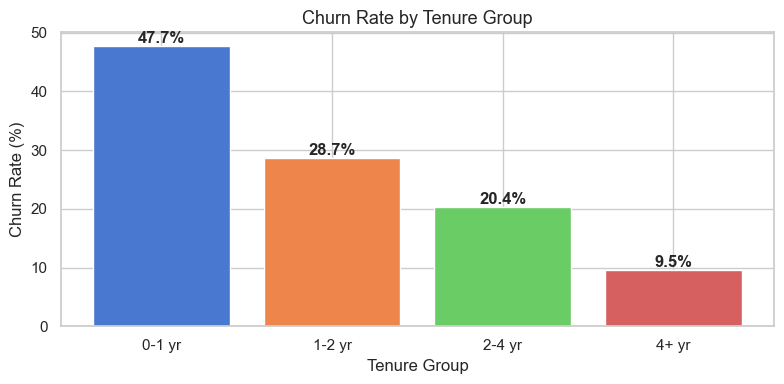

In [13]:
df['tenure_group'] = pd.cut(df['tenure'],
                             bins=[0, 12, 24, 48, 72],
                             labels=['0-1 yr', '1-2 yr', '2-4 yr', '4+ yr'])

tenure_churn = df.groupby('tenure_group')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
tenure_churn.columns = ['tenure_group', 'ChurnRate']

plt.figure(figsize=(8, 4))
bars = plt.bar(tenure_churn['tenure_group'].astype(str), tenure_churn['ChurnRate'],
               color=sns.color_palette('muted', 4), edgecolor='white')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', fontweight='bold')
plt.title('Churn Rate by Tenure Group', fontsize=13)
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

# Drop the temp column
df.drop(columns=['tenure_group'], inplace=True)

## 8. Findings

Summarize the main results and the points to carry into modeling.

In [14]:
findings = """
EDA key findings

1. Class imbalance
   - about 73% no churn and 27% churn
   - use ROC-AUC and F1 instead of accuracy
   - consider class_weight='balanced' or resampling

2. Tenure
   - churn is higher for customers with low tenure
   - tenure is one of the strongest signals

3. MonthlyCharges
   - churned customers pay more on average

4. Contract
   - month-to-month contracts have much higher churn
   - 1-year and 2-year contracts are more stable

5. InternetService
   - fiber optic customers churn more than DSL or no internet

6. PaymentMethod
   - electronic check users churn more often

7. TotalCharges
   - total charges are tied to tenure
   - missing values are mostly new customers with zero tenure

8. SeniorCitizen
   - senior customers have higher churn rates

Model notes
   - use tenure, MonthlyCharges, Contract, InternetService, PaymentMethod
   - encode categorical variables
   - scale numeric features
   - evaluate with ROC-AUC, F1, precision, recall
"""
print(findings)


EDA key findings

1. Class imbalance
   - about 73% no churn and 27% churn
   - use ROC-AUC and F1 instead of accuracy
   - consider class_weight='balanced' or resampling

2. Tenure
   - churn is higher for customers with low tenure
   - tenure is one of the strongest signals

3. MonthlyCharges
   - churned customers pay more on average

4. Contract
   - month-to-month contracts have much higher churn
   - 1-year and 2-year contracts are more stable

5. InternetService
   - fiber optic customers churn more than DSL or no internet

6. PaymentMethod
   - electronic check users churn more often

7. TotalCharges
   - total charges are tied to tenure
   - missing values are mostly new customers with zero tenure

8. SeniorCitizen
   - senior customers have higher churn rates

Model notes
   - use tenure, MonthlyCharges, Contract, InternetService, PaymentMethod
   - encode categorical variables
   - scale numeric features
   - evaluate with ROC-AUC, F1, precision, recall



## EDA complete
Next: `02_modeling.ipynb` for preprocessing, feature engineering, model training and evaluation.